In [8]:
# IMPORTS

import os
import re
import json
import math
import time
import random
import glob
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

from src.instance import (
    load_instance, fix_proposal_windows, build_patterns,
    print_summary, create_instance_summary, load_n_from_dir
)
from src.solution import Solution, decode, evaluate, copy_solution
from src.constructive import (
    greedy_pattern_first_scarcity2, multistart_greedy, grasp
)
from src.metaheuristic import (
    FirstImprovement, SteepestImprovement,
    SimulatedAnnealing, SimulatedAnnealingAdaptiveAlpha,
    TabuSearch, VNS, IteratedLocalSearch, SAInfeasible
)
from src.utils import (
    print_solution_state, print_cost_breakdown,
    save_solution_json, load_solution_json,
    reconstruct_solution, solution_exists
)
from src.visualize_stocks import visualize_solution, visualize_solution_detail
from src.runner import run_method, METHODS_CONFIG
from src.data_generator import (
    generate_instance, save_json,
    BASELINE, BASELINE_SIZE_CONFIG,
    FIXED_SIZE_CONFIGS,
    SWEEP_DEFECT, SWEEP_DEFECT_LABELS,
    SWEEP_DEMAND, SWEEP_DEMAND_LABELS,
    SWEEP_LENGTH_RATIO, SWEEP_LENGTH_RATIO_LABELS,
    SWEEP_WIDTH_RATIO, SWEEP_WIDTH_RATIO_LABELS,
    SWEEP_SIZE, SWEEP_SIZE_LABELS,
    generate_sensitivity_sweep,
)

# Generation of data

## Generate one individual instance

In [9]:
# GENERATE ONE INSTANCE

output_dir = "../data/sensitivity/baseline"
os.makedirs(output_dir, exist_ok=True)

instance = generate_instance(
    size_class                 = "medium",
    defect_length_ratio        = BASELINE["defect_length_ratio"],
    demand_tightness           = BASELINE["demand_tightness"],
    stock_product_length_ratio = BASELINE["stock_product_length_ratio"],
    stock_product_width_ratio  = BASELINE["stock_product_width_ratio"],
    size_config                = BASELINE_SIZE_CONFIG,
    seed                       = 0,
    instance_id                = "SYN_BASELINE_000",
    verbose                    = True,
)
save_json(instance, os.path.join(output_dir, "SYN_BASELINE_000.json"))

  [SYN_BASELINE_000] attempt=1  P=14  S=54  props=6819  defect_ratio=0.278  tightness=0.321  len_ratio=2.60  feasible=True


## Generate all the instances

In [ ]:
# GENERATE ALL INSTANCES

generate_sensitivity_sweep(
    output_dir  = '../data/sensitivity/',
    n_per_point = 30,
    n_baseline  = 150,
    n_per_size  = 60,
    base_seed   = 0,
    verbose     = True,
)

  [SYN_BASELINE_000] attempt=1  P=14  S=54  props=12410  defect_ratio=0.267  tightness=0.273  len_ratio=2.58  feasible=True


# Loading 

In [15]:
# LOAD INSTANCES
import importlib
import src.instance
importlib.reload(src.instance)
from src.instance import load_instance, fix_proposal_windows, build_patterns, load_n_from_dir, print_summary, create_instance_summary
SENSITIVITY_DIR = r'C:\Users\Isabelle\Documents\these\Data\testing'
OMP_DIR         = r'C:\Users\Isabelle\Documents\these\Data\omp_instances_updated'

# to load a category, change its "n" from 0 to the number of instances wanted
CATEGORIES = {
    "baseline"     : {"dir": os.path.join(SENSITIVITY_DIR, "baseline"),            "n": 10, "label": None},
    "sweep1_Low"   : {"dir": os.path.join(SENSITIVITY_DIR, "sweep1_defect"),       "n": 0,  "label": "LOW"},
    "sweep1_High"  : {"dir": os.path.join(SENSITIVITY_DIR, "sweep1_defect"),       "n": 0,  "label": "HIGH"},
    "sweep2_Loose" : {"dir": os.path.join(SENSITIVITY_DIR, "sweep2_demand"),       "n": 0,  "label": "LOOSE"},
    "sweep2_Tight" : {"dir": os.path.join(SENSITIVITY_DIR, "sweep2_demand"),       "n": 0,  "label": "TIGHT"},
    "sweep3_Short" : {"dir": os.path.join(SENSITIVITY_DIR, "sweep3_length_ratio"), "n": 0,  "label": "SHORT"},
    "sweep3_Long"  : {"dir": os.path.join(SENSITIVITY_DIR, "sweep3_length_ratio"), "n": 0,  "label": "LONG"},
    "sweep4_Low"   : {"dir": os.path.join(SENSITIVITY_DIR, "sweep4_width_ratio"),  "n": 0,  "label": "LOW"},
    "sweep4_High"  : {"dir": os.path.join(SENSITIVITY_DIR, "sweep4_width_ratio"),  "n": 0,  "label": "HIGH"},
    "sweep5_XS"    : {"dir": os.path.join(SENSITIVITY_DIR, "sweep5_size"),         "n": 0,  "label": "XS"},
    "sweep5_S"     : {"dir": os.path.join(SENSITIVITY_DIR, "sweep5_size"),         "n": 0,  "label": "S"},
    "sweep5_L"     : {"dir": os.path.join(SENSITIVITY_DIR, "sweep5_size"),         "n": 0,  "label": "L"},
    "sweep5_XL"    : {"dir": os.path.join(SENSITIVITY_DIR, "sweep5_size"),         "n": 0,  "label": "XL"},
}

# to load OMP instances, change N_OMP from 0 to the number wanted
N_OMP   = 0
SHUFFLE = False

instances = []

for cat, cfg in CATEGORIES.items():
    if cfg["n"] == 0:
        continue
    loaded = load_n_from_dir(cfg["dir"], cfg["n"], cfg["label"])
    for inst in loaded:
        inst["category"] = cat
    if SHUFFLE:
        random.shuffle(loaded)
    instances += loaded
    print(f"  [{cat}] {len(loaded)} instances")

if N_OMP > 0:
    omp = load_n_from_dir(OMP_DIR, N_OMP)
    for inst in omp:
        inst["category"] = "omp"
    if SHUFFLE:
        random.shuffle(omp)
    instances += omp
    print(f"  [omp] {len(omp)} instances")

print(f"\n  Total: {len(instances)} instances")   

  Loaded SYN_BASELINE_050  |  raw=90620  fixed=90620  patterns=5260
  Loaded SYN_BASELINE_051  |  raw=4958  fixed=4958  patterns=237
  Loaded SYN_BASELINE_052  |  raw=2344  fixed=2344  patterns=196
  Loaded SYN_BASELINE_053  |  raw=3703  fixed=3703  patterns=234
  Loaded SYN_BASELINE_054  |  raw=3101  fixed=3101  patterns=160
  Loaded SYN_BASELINE_055  |  raw=3918  fixed=3918  patterns=255
  Loaded SYN_BASELINE_056  |  raw=4451  fixed=4451  patterns=233
  Loaded SYN_BASELINE_057  |  raw=5187  fixed=5187  patterns=237
  Loaded SYN_BASELINE_058  |  raw=8960  fixed=8960  patterns=857
  Loaded SYN_BASELINE_059  |  raw=2323  fixed=2323  patterns=286
  [baseline] 10 instances

  Total: 10 instances


# Visualize one instance

You can visualize any loaded instance by changing the category name and the idx to the corresponding instance

  Selected: SYN_BASELINE_050


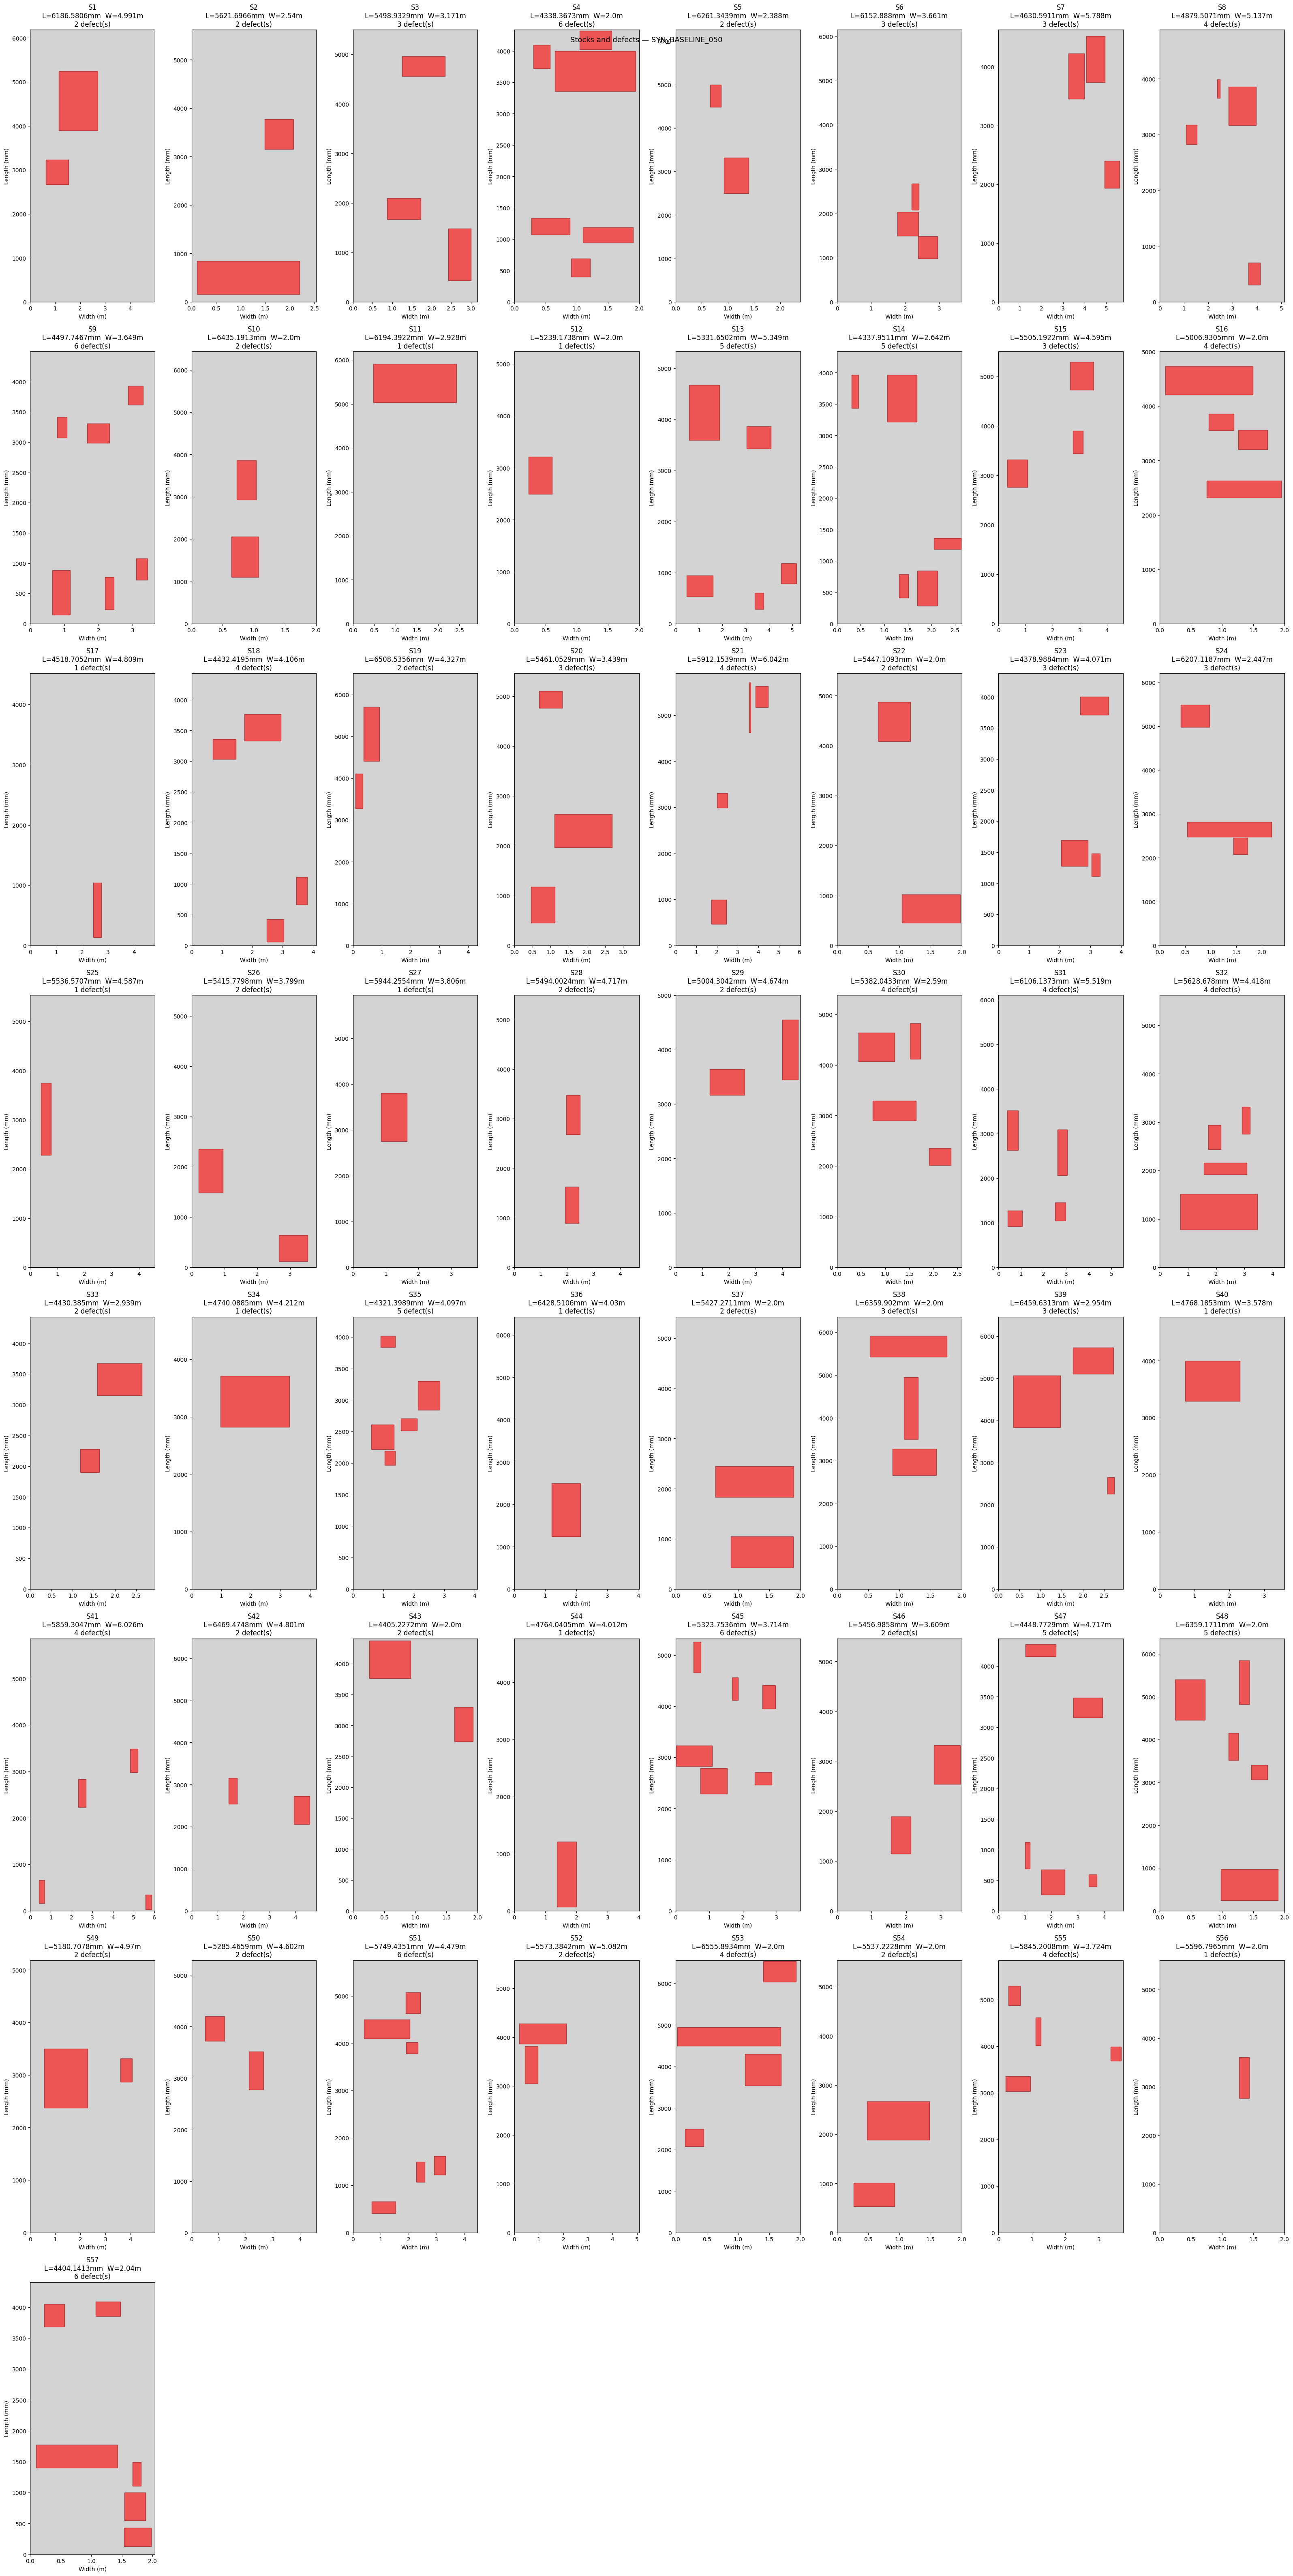

In [16]:
# VISUALIZE INSTANCE STOCKS AND DEFECTS

CATEGORY = "baseline"
IDX      = 0

cat_instances = [i for i in instances if i["category"] == CATEGORY]
inst          = cat_instances[IDX]
stocks        = inst['stocks']

print(f"  Selected: {inst['name']}")

max_cols = 8
n        = len(stocks)
n_cols   = min(max_cols, n)
n_rows   = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 8 * n_rows))

if n_rows == 1 and n_cols == 1:
    axes_flat = [axes]
elif n_rows == 1:
    axes_flat = list(axes)
else:
    axes_flat = [ax for row in axes for ax in row]

for ax, (sid, stock) in zip(axes_flat, stocks.items()):
    ax.add_patch(mpatches.Rectangle(
        (0, 0), stock.width, stock.length,
        linewidth=1, edgecolor='black', facecolor='lightgrey'
    ))
    for d in stock.defects:
        ax.add_patch(mpatches.Rectangle(
            (d.start_in_width, d.start_in_length),
            d.width, d.length,
            linewidth=1, edgecolor='darkred', facecolor='red', alpha=0.6
        ))
    ax.set_xlim(0, stock.width)
    ax.set_ylim(0, stock.length)
    ax.set_xlabel('Width (m)')
    ax.set_ylabel('Length (mm)')
    ax.set_title(f"{sid}\nL={stock.length}mm  W={stock.width}m\n{len(stock.defects)} defect(s)")

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle(f'Stocks and defects — {inst["name"]}', fontsize=13)
plt.tight_layout()
plt.show()

# Create excel summary file per instance

In [ ]:
# CREATE INSTANCE SUMMARY — ONE INSTANCE

CATEGORY   = "baseline"
IDX        = 0
OUTPUT_DIR = "../outputs/instance_summaries"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cat_instances = [i for i in instances if i["category"] == CATEGORY]
inst          = cat_instances[IDX]

create_instance_summary(
    stocks          = inst['stocks'],
    products        = inst['products'],
    patterns        = inst['patterns'],
    filepath        = os.path.join(OUTPUT_DIR, f"{inst['name']}_summary.xlsx"),
    instance_name   = inst['name'],
    proposals_raw   = inst['proposals_raw'],
)

Saved: ../outputs/instance_summaries\SYN_BASELINE_050_summary.xlsx


In [ ]:
# CREATE INSTANCE SUMMARY — ALL LOADED INSTANCES

OUTPUT_DIR = r"C:\Users\Isabelle\Documents\these\outputs\instance_summaries"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for inst in instances:
    create_instance_summary(
        stocks          = inst['stocks'],
        products        = inst['products'],
        patterns        = inst['patterns'],
        filepath        = os.path.join(OUTPUT_DIR, f"{inst['name']}_summary.xlsx"),
        instance_name   = inst['name'],
        proposals_raw   = inst['proposals_raw'],
    )
    print(f"  Saved {inst['name']}_summary.xlsx")

print(f"\n  Done — {len(instances)} summaries saved to {OUTPUT_DIR}")

Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_050_summary.xlsx
  Saved SYN_BASELINE_050_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_051_summary.xlsx
  Saved SYN_BASELINE_051_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_052_summary.xlsx
  Saved SYN_BASELINE_052_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_053_summary.xlsx
  Saved SYN_BASELINE_053_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_054_summary.xlsx
  Saved SYN_BASELINE_054_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_055_summary.xlsx
  Saved SYN_BASELINE_055_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs\instance_summaries\SYN_BASELINE_056_summary.xlsx
  Saved SYN_BASELINE_056_summary.xlsx
Saved: C:\Users\Isabelle\Documents\these\outputs

# Running the Results

This cell runs a single method on a single instance without saving to disk, and prints the solution state directly. To change the method or instance, edit METHOD, START_METHOD, CATEGORY and IDX.

In [12]:
# RUN ONE METHOD ON ONE INSTANCE

import importlib
import src.solution, src.constructive, src.metaheuristic
importlib.reload(src.solution)
importlib.reload(src.constructive)
importlib.reload(src.metaheuristic)
from src.constructive import multistart_greedy, greedy_pattern_first_scarcity2
from src.metaheuristic import FirstImprovement

CATEGORY     = "omp"
IDX          = 0
TIME_LIMIT   = 60.0
SEED         = 42

cat_instances = [i for i in instances if i["category"] == CATEGORY]
instance      = cat_instances[IDX]
stocks, products, patterns = instance['stocks'], instance['products'], instance['patterns']

# build starting solution
sol = multistart_greedy(patterns, stocks, products)

# run method
ls  = FirstImprovement(stocks, products, patterns, time_limit=TIME_LIMIT, seed=SEED)
sol, _, _, _ = ls.run(sol)

# print
print_solution_state(sol, stocks, products, label="FI + multistart")

  Scarce products (10% threshold): ['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P2', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30', 'P31', 'P32', 'P33', 'P34', 'P35', 'P4', 'P6', 'P7', 'P8', 'P9']
  Phase 1: 803 patterns in scarce pool
  Phase 1 done. Remaining scarce unmet: {'P31': 3, 'P9': 5}
  Phase 2: covering remaining 3 products
  Unmet demand remaining: {'P9': 5, 'P31': 3}
P1: unmet=0  remaining_capacity=295
P2: unmet=0  remaining_capacity=1
P3: unmet=0  remaining_capacity=39
P4: unmet=0  remaining_capacity=21
P5: unmet=0  remaining_capacity=897
P6: unmet=0  remaining_capacity=9
P7: unmet=0  remaining_capacity=6
P8: unmet=0  remaining_capacity=176
P9: unmet=5  remaining_capacity=0
P10: unmet=0  remaining_capacity=2
P11: unmet=0  remaining_capacity=3
P12: unmet=0  remaining_capacity=523
P13: unmet=0  remaining_capacity=130
P14: unmet=0  remaining_capacity=3
P15: unmet=0  remaining_capacity=9
P16: unmet=0  remaining_capacity

This cell is based on runner.py which contains the method configurations (METHODS_CONFIG) and output paths (RESULTS_DIR, SOLUTIONS_DIR). It runs the selected methods on all loaded instances and saves results to Excel.
To control what runs, edit METHOD_STARTS: the keys are the method names and the values are the starting heuristics. Constructive methods (greedy, multistart) always use "none". Local search methods (FI, SD, SA, TS, VNS_SA, ILS_SA) can use "greedy" or "multistart" as starting heuristic, you can specify one or both. To run fewer methods just remove the corresponding rows. To change the time budget or seed, edit TIME_LIMIT and BASE_SEED. To change the output path, edit RESULTS_DIR and SOLUTIONS_DIR directly in runner.py.

In [18]:
import importlib
import src.solution, src.constructive, src.metaheuristic, src.runner
importlib.reload(src.solution)
importlib.reload(src.constructive)
importlib.reload(src.metaheuristic)
importlib.reload(src.runner)
from src.runner import run_method, RESULTS_DIR, SOLUTIONS_DIR, METHODS_CONFIG

TIME_LIMIT    = 60.0
BASE_SEED     = 42
SKIP_EXISTING = True

os.makedirs(RESULTS_DIR,   exist_ok=True)
os.makedirs(SOLUTIONS_DIR, exist_ok=True)

METHOD_STARTS = {
    # constructive methods — start = "none"
    "greedy"    : ["none"],
    "multistart": ["none"],

    # local search methods — start = "greedy" or "multistart"
    "FI"        : ["greedy", "multistart"],
    "SD"        : ["greedy", "multistart"],
    "TS"        : ["greedy", "multistart"],
    "SA"        : ["greedy", "multistart"],
    "VNS_SA"    : ["greedy", "multistart"],
    "ILS_SA"    : ["greedy", "multistart"],
    "GRASP_SA"  : ["none"],
}

total_runs     = len(instances) * sum(len(s) for s in METHOD_STARTS.values())
completed      = 0
rows_by_method = {m: [] for m in METHOD_STARTS}

def save_method_excel(method_name, rows):
    if not rows:
        return
    output = os.path.join(RESULTS_DIR, f"{method_name}_TL{int(TIME_LIMIT)}.xlsx")
    with pd.ExcelWriter(output, engine="openpyxl") as writer:
        pd.DataFrame(rows).to_excel(writer, sheet_name="detail", index=False)

print(f"Running {len(instances)} instances x "
      f"{sum(len(s) for s in METHOD_STARTS.values())} combos "
      f"= {total_runs} total runs")
print(f"{'='*60}")

for instance in instances:
    name = instance['name']
    print(f"\n  {name}  [{instance['category']}]")
    print(f"  {'─'*50}")

    for method_name, start_methods in METHOD_STARTS.items():
        for start_method in start_methods:
            completed += 1

            row = run_method(
                method_name   = method_name,
                start_method  = start_method,
                instance      = instance,
                config        = METHODS_CONFIG,
                time_limit    = TIME_LIMIT,
                seed          = BASE_SEED,
                skip_existing = SKIP_EXISTING,
                verbose       = False,
            )

            row["category"] = instance["category"]
            rows_by_method[method_name].append(row)

            cost_s = f"{row['final_cost']:.2f}" if row["final_cost"] else "None"
            el_s   = f"{row['elapsed_sec']:.1f}s" if row["elapsed_sec"] else "None"
            err_s  = f"  ERR: {row['error']}" if row["error"] else ""
            print(f"    [{completed:3d}/{total_runs}]  "
                  f"{method_name:<12} + {start_method:<10}  "
                  f"cost={cost_s:<12}  "
                  f"feasible={'Y' if row['is_feasible'] else 'N'}  "
                  f"elapsed={el_s}{err_s}")

        # incremental save after each method x instance
        save_method_excel(method_name, rows_by_method[method_name])

print(f"\n  Done. Files saved to {RESULTS_DIR}")

Running 10 instances x 15 combos = 150 total runs

  SYN_BASELINE_050  [baseline]
  ──────────────────────────────────────────────────
  Scarce products (10% threshold): ['P1', 'P12', 'P13', 'P14', 'P15', 'P2', 'P3', 'P5', 'P6', 'P7']
  Phase 1: 260 patterns in scarce pool
  Phase 1 done. Remaining scarce unmet: {}
  Phase 2: covering remaining 5 products
    [  1/150]  greedy       + none        cost=12365.71      feasible=Y  elapsed=1.3s
  Scarce products (10% threshold): ['P1', 'P12', 'P13', 'P14', 'P15', 'P2', 'P3', 'P5', 'P6', 'P7']
  Phase 1: 260 patterns in scarce pool
  Phase 1 done. Remaining scarce unmet: {}
  Phase 2: covering remaining 5 products


KeyboardInterrupt: 

# Merging the results from the runner and create summaries

In [ ]:
"""
merge_results.py
----------------
Merges all per-method result Excel files into one master Excel file.

This script is READ-ONLY with respect to input files.
It never modifies any input file — it only creates a new output file.

The greedy reference cost is taken from feasible greedy rows already present
in the result files. It is never recomputed here.

Output sheets:
  raw              -- clean raw rows with only relevant columns
  summary_baseline -- median + mean improvement per method x start (baseline only)
  summary_all      -- same across all categories
  summary_cat      -- same split by category
  pivot_mean       -- pivot: method x start vs category, mean improvement
  pivot_median     -- pivot: method x start vs category, median improvement

Metric:
  improvement_pct = (greedy_cost - method_cost) / greedy_cost * 100
  Positive = better than greedy. Only computed when both method and greedy are feasible.
"""

import os
import re
import glob

import pandas as pd
import numpy as np


# CONFIG — overridden by notebook cell when called from notebook
INPUT_DIR   = r"C:\Users\Isabelle\Documents\outputs\results\final" #path to the folder with all the excel files
OUTPUT_PATH = r"C:\Users\Isabelle\Documents\outputs\results\master_results.xlsx"
DETAIL_SHEET = "detail"

CATEGORY_MAP = {
    "baseline"    : "Baseline",
    "sweep1_Low"  : "Defect density - Low",
    "sweep1_High" : "Defect density - High",
    "sweep2_Loose": "Demand - Loose",
    "sweep2_Tight": "Demand - Tight",
    "sweep3_Short": "Length - Short",
    "sweep3_Long" : "Length - Long",
    "sweep4_Low"  : "Width - Narrow",
    "sweep4_High" : "Width - Wide",
    "sweep5_XS"   : "Size - XS",
    "sweep5_S"    : "Size - S",
    "sweep5_L"    : "Size - L",
    "sweep5_XL"   : "Size - XL",
    "omp"         : "OMP Instances",
}

METHOD_ORDER = ["greedy", "multistart", "FI", "SD", "TS", "SA", "VNS_SA", "ILS_SA", "GRASP_SA"]


# LOAD XLSX FILES

files = sorted(glob.glob(os.path.join(INPUT_DIR, "**", "*.xlsx"), recursive=True))
files = [f for f in files if os.path.basename(f) != os.path.basename(OUTPUT_PATH)]

print(f"Found {len(files)} xlsx files (read-only):")
for f in files:
    print(f"  {os.path.basename(f)}")

frames = []
for f in files:
    fname = os.path.basename(f)
    try:
        xl = pd.ExcelFile(f)
        if DETAIL_SHEET not in xl.sheet_names:
            print(f"  [SKIP] {fname} - no '{DETAIL_SHEET}' sheet")
            continue
        df = pd.read_excel(f, sheet_name=DETAIL_SHEET)
        df["source_file"] = fname
        frames.append(df)
        print(f"  [OK]   {fname}  ->  {len(df)} rows")
    except Exception as e:
        print(f"  [ERR]  {fname}: {e}")

if not frames:
    raise RuntimeError("No files loaded - check INPUT_DIR and DETAIL_SHEET name.")

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows before dedup: {len(raw)}")


# DEDUPLICATION

raw = (
    raw.sort_values("final_cost", ascending=True)
    .drop_duplicates(subset=["instance", "method", "start_method"], keep="first")
    .reset_index(drop=True)
)
print(f"Total rows after dedup: {len(raw)}")


# INFER CATEGORY

def infer_category(row):
    if pd.notna(row.get("category")):
        return row["category"]
    name = str(row["instance"]).upper()
    if "BASELINE"            in name: return "baseline"
    if "SWEEP1_DEFECT_HIGH"  in name: return "sweep1_High"
    if "SWEEP1_DEFECT_LOW"   in name: return "sweep1_Low"
    if "SWEEP2_DEMAND_LOOSE" in name: return "sweep2_Loose"
    if "SWEEP2_DEMAND_TIGHT" in name: return "sweep2_Tight"
    if "SWEEP3" in name and "LONG"  in name: return "sweep3_Long"
    if "SWEEP3" in name and "SHORT" in name: return "sweep3_Short"
    if "SWEEP4" in name and "HIGH"  in name: return "sweep4_High"
    if "SWEEP4" in name and "LOW"   in name: return "sweep4_Low"
    if "SWEEP5" in name and "_XS"   in name: return "sweep5_XS"
    if "SWEEP5" in name and "_S_"   in name: return "sweep5_S"
    if "SWEEP5" in name and "_XL"   in name: return "sweep5_XL"
    if "SWEEP5" in name and "_L_"   in name: return "sweep5_L"
    if "OMP"                 in name: return "omp"
    if re.match(r"^\d{14}_", str(row["instance"])): return "omp"
    return None

if "category" not in raw.columns:
    raw["category"] = None
raw["category"]       = raw.apply(infer_category, axis=1)
raw["category_clean"] = raw["category"].map(CATEGORY_MAP).fillna(raw["category"])


# GREEDY REFERENCE

greedy_ref = (
    raw[(raw["method"] == "greedy") & (raw["is_feasible"] == True)]
    [["instance", "final_cost"]]
    .rename(columns={"final_cost": "greedy_ref"})
    .drop_duplicates(subset=["instance"])
)
print(f"\nInstances with feasible greedy reference: {len(greedy_ref)}")
missing_greedy = set(raw["instance"].unique()) - set(greedy_ref["instance"].unique())
if missing_greedy:
    print(f"Instances with NO feasible greedy: {sorted(missing_greedy)}")

raw = raw.drop(columns=["greedy_ref"], errors="ignore")
raw = raw.merge(greedy_ref, on="instance", how="left")


# IMPROVEMENT PCT

raw["improvement_pct"] = np.nan
mask = (
    raw["greedy_ref"].notna() &
    (raw["is_feasible"] == True)
)
raw.loc[mask, "improvement_pct"] = (
    (raw.loc[mask, "greedy_ref"] - raw.loc[mask, "final_cost"])
    / raw.loc[mask, "greedy_ref"] * 100
).round(4)

print(f"improvement_pct computed: {mask.sum()} rows")
print(f"improvement_pct null: {raw['improvement_pct'].isna().sum()} rows")


# KEEP RELEVANT COLUMNS

keep_cols = [
    "instance", "category", "category_clean",
    "method", "start_method",
    "greedy_ref", "final_cost", "is_feasible",
    "improvement_pct", "elapsed_sec",
    "unmet", "open_stocks", "source_file",
]
keep_cols = [c for c in keep_cols if c in raw.columns]
raw = raw[keep_cols]


# SUMMARIES

def make_summary(df, groupby_cols):
    return df.groupby(groupby_cols, dropna=False).agg(
        n_instances        = ("instance",        "count"),
        mean_improvement   = ("improvement_pct", "mean"),
        median_improvement = ("improvement_pct", "median"),
        std_improvement    = ("improvement_pct", "std"),
        min_improvement    = ("improvement_pct", "min"),
        max_improvement    = ("improvement_pct", "max"),
        feasibility_rate   = ("is_feasible",     lambda x: round(100 * x.sum() / len(x), 1)),
        mean_elapsed       = ("elapsed_sec",     "mean"),
    ).round(4).reset_index()

def method_sort_key(m):
    try:    return METHOD_ORDER.index(m)
    except: return 999

summary_base = make_summary(raw[raw["category"] == "baseline"], ["method", "start_method"])
summary_base["_sort"] = summary_base["method"].apply(method_sort_key)
summary_base = summary_base.sort_values(["_sort", "start_method"]).drop(columns="_sort").reset_index(drop=True)

summary_all = make_summary(raw, ["method", "start_method"])
summary_all["_sort"] = summary_all["method"].apply(method_sort_key)
summary_all = summary_all.sort_values(["_sort", "start_method"]).drop(columns="_sort").reset_index(drop=True)

summary_cat = make_summary(raw, ["method", "start_method", "category_clean"])
summary_cat["_sort"] = summary_cat["method"].apply(method_sort_key)
summary_cat = summary_cat.sort_values(["_sort", "start_method", "category_clean"]).drop(columns="_sort").reset_index(drop=True)

def make_pivot(df, value_col):
    pivot = df.pivot_table(
        index   = ["method", "start_method"],
        columns = "category_clean",
        values  = value_col,
    ).round(2)
    cols = sorted(pivot.columns)
    if "Baseline" in cols:
        cols = ["Baseline"] + [c for c in cols if c != "Baseline"]
    return pivot[cols]

pivot_mean   = make_pivot(summary_cat, "mean_improvement")
pivot_median = make_pivot(summary_cat, "median_improvement")


# SAVE

print(f"\nSaving to {OUTPUT_PATH} ...")
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    raw.to_excel(writer,          sheet_name="raw",              index=False)
    summary_base.to_excel(writer, sheet_name="summary_baseline", index=False)
    summary_all.to_excel(writer,  sheet_name="summary_all",      index=False)
    summary_cat.to_excel(writer,  sheet_name="summary_cat",      index=False)
    pivot_mean.to_excel(writer,   sheet_name="pivot_mean")
    pivot_median.to_excel(writer, sheet_name="pivot_median")

print("Done.")
print(f"\n-- summary_baseline preview --")
print(summary_base[[
    "method", "start_method", "n_instances",
    "mean_improvement", "median_improvement",
    "std_improvement", "feasibility_rate"
]].to_string(index=False))

Found 7 xlsx files (read-only):
  GRASP_TL60.xlsx
  ILS_SA_TL60.xlsx
  SA_TL60.xlsx
  TS_TL60.xlsx
  ILS_SA_TL60.xlsx
  SA_TL60.xlsx
  TS_TL60.xlsx
  [OK]   GRASP_TL60.xlsx  ->  11 rows
  [OK]   ILS_SA_TL60.xlsx  ->  11 rows
  [OK]   SA_TL60.xlsx  ->  11 rows
  [OK]   TS_TL60.xlsx  ->  11 rows
  [OK]   ILS_SA_TL60.xlsx  ->  9 rows
  [OK]   SA_TL60.xlsx  ->  9 rows
  [OK]   TS_TL60.xlsx  ->  18 rows

Total rows before dedup: 80
Total rows after dedup: 71

Instances with feasible greedy reference: 0
Instances with NO feasible greedy: ['20260416122013_35Orders70Stocks', '20260416130056_39Orders48Stocks', '20260416130720_18Orders44Stocks', '20260416141254_41Orders54Stocks', '20260416155533_21Orders39Stocks', '20260416162037_39Orders66Stocks', '20260416162639_4Orders7Stocks', '20260416164151_20Orders27Stocks', '20260416165146_25Orders42Stocks', '20260416165727_19Orders46Stocks', '20260416174610_38Orders69Stocks']
improvement_pct computed: 0 rows
improvement_pct null: 71 rows

Saving to C:\U

# Visualize solutions

## only one solution


  SA + greedy
  Cost        : 6155.5840
  Unmet       : {}
  Overproduced: {}
  Fully placed: True
  Stocks used : 12
    S19:
      PAT_0045  entry=0  [0 -> 1228]  produces={'P3': 3}
      PAT_0045  entry=0  [1228 -> 2456]  produces={'P3': 3}
      PAT_0083  entry=1  [2456 -> 4706]  produces={'P6': 1, 'P9': 2}
    S22:
      PAT_0115  entry=0  [0 -> 2250]  produces={'P4': 2, 'P9': 4}
      PAT_0129  entry=0  [2250 -> 5103]  produces={'P5': 4}
    S15:
      PAT_0071  entry=0  [0 -> 2250]  produces={'P4': 2, 'P6': 1}
      PAT_0071  entry=0  [2250 -> 4500]  produces={'P4': 2, 'P6': 1}
    S4:
      PAT_0016  entry=0  [713 -> 3386]  produces={'P8': 4}
    S20:
      PAT_0092  entry=0  [493 -> 2743]  produces={'P10': 1, 'P6': 2}
    S26:
      PAT_0064  entry=0  [0 -> 2250]  produces={'P10': 3}
    S2:
      PAT_0027  entry=0  [0 -> 2673]  produces={'P2': 1, 'P8': 2}
      PAT_0126  entry=0  [2673 -> 5527]  produces={'P5': 1}
    S29:
      PAT_0003  entry=0  [0 -> 3047]  produces={'P1'

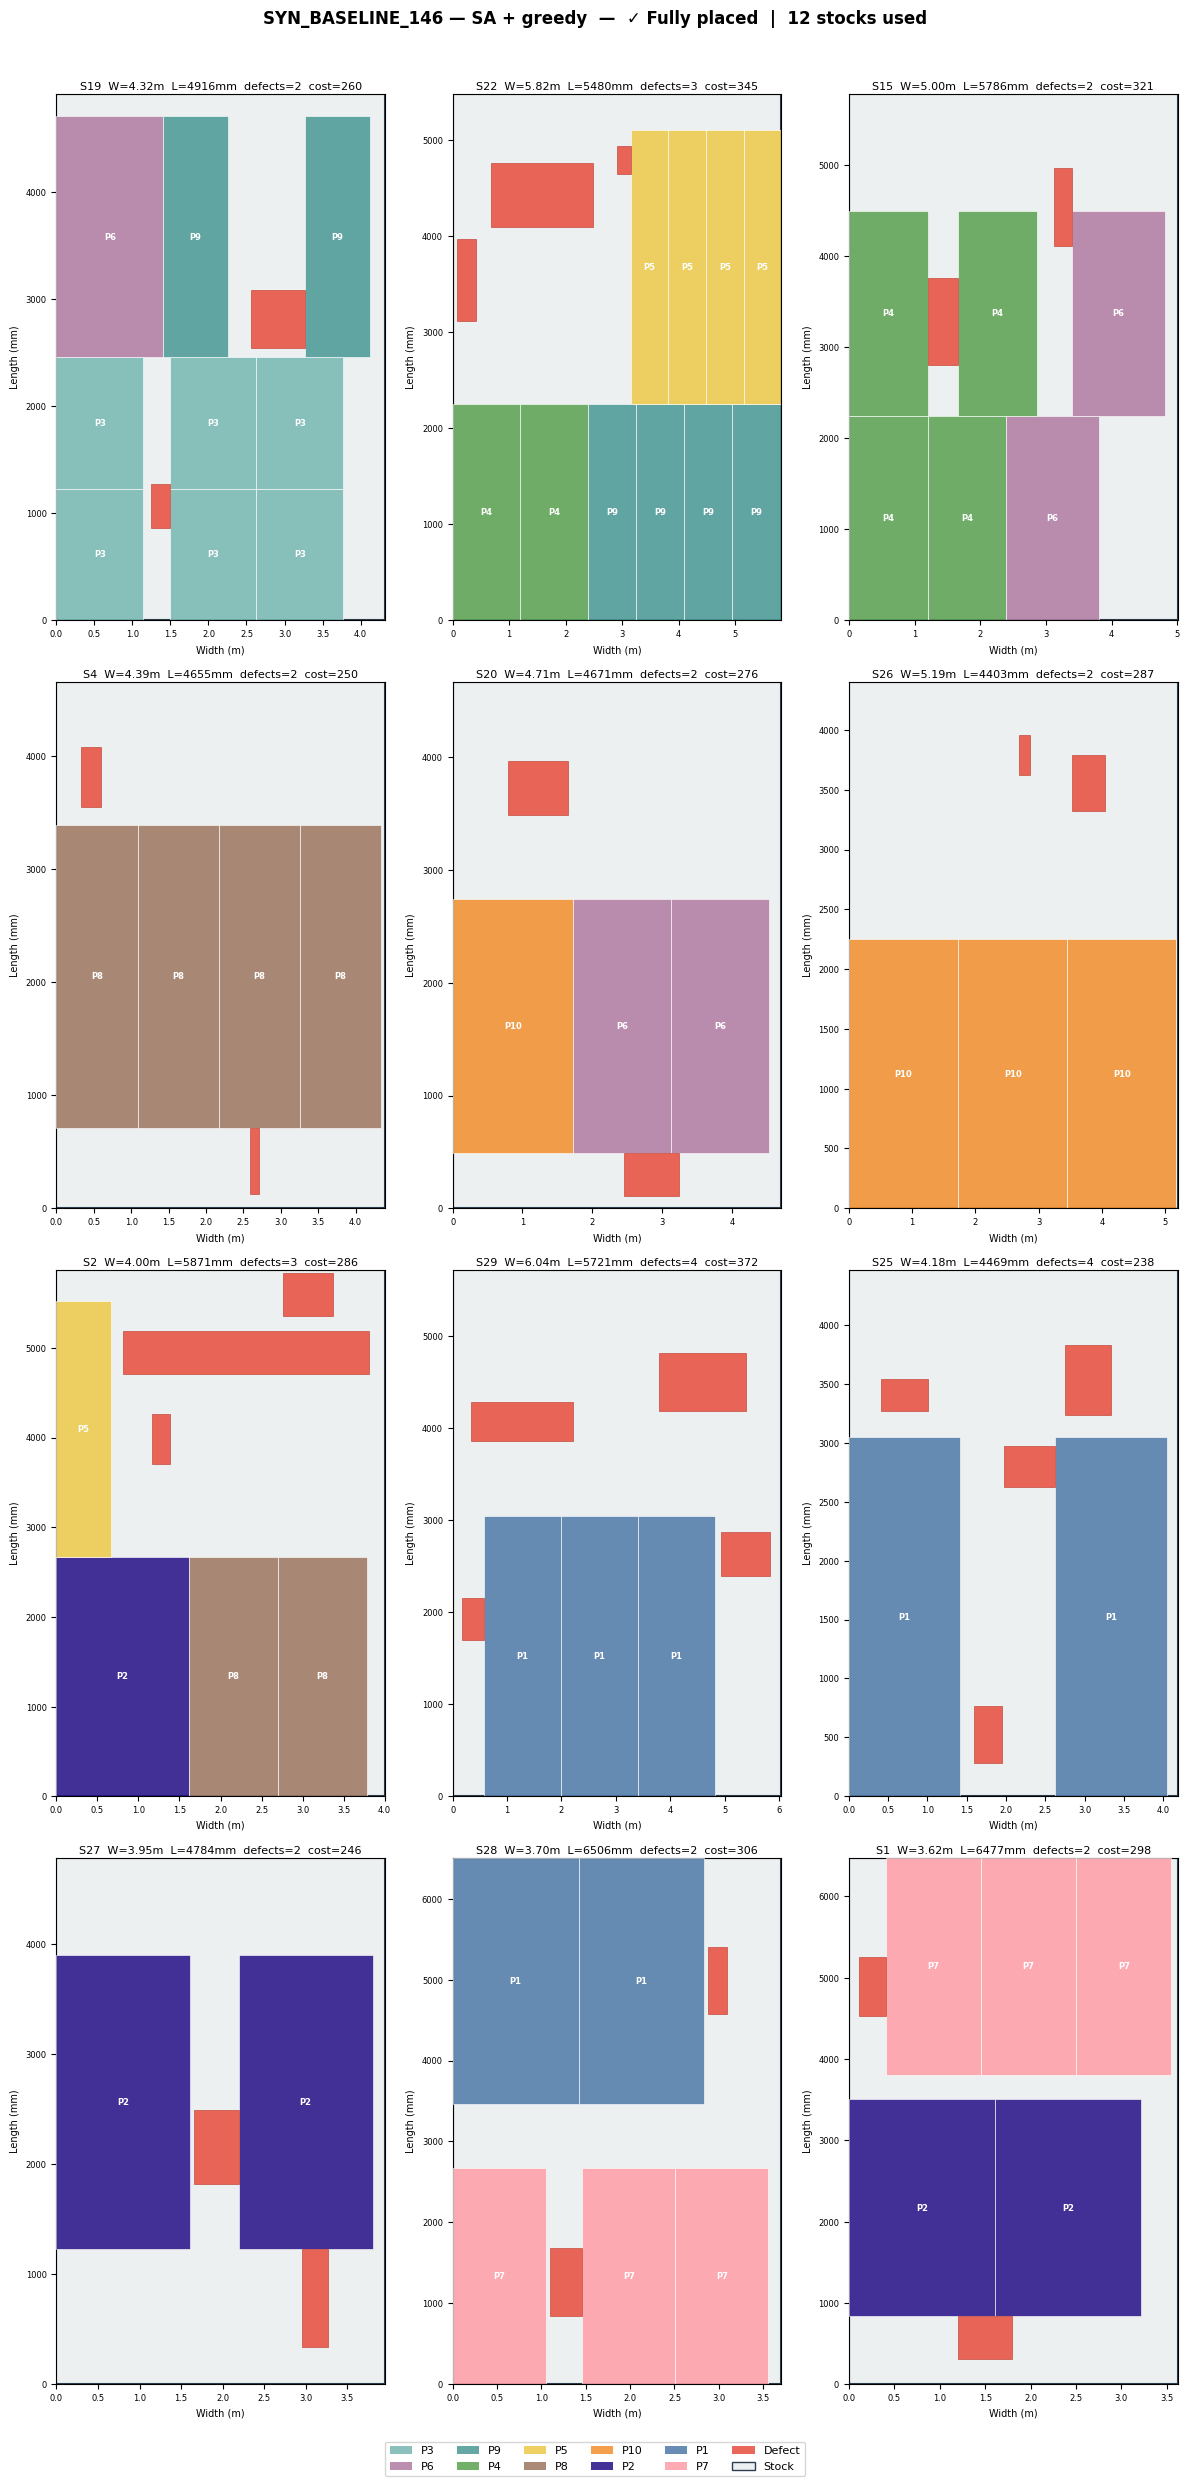

In [7]:
# VISUALIZE ONE SOLUTION
import os
import importlib
import src.visualize_stocks as vs
importlib.reload(vs)
from src.visualize_stocks import visualize_solution, visualize_solution_to_pdf
from src.utils import load_solution_json, reconstruct_solution, print_solution_state, print_cost_breakdown

SOLUTIONS_DIR = r"C:\Users\Isabelle\Documents\outputs\solutions"
OUTPUT_DIR    = r"C:\Users\Isabelle\Documents\these\pdfs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CATEGORY     = "baseline"
IDX          = 96
METHOD       = "SA"
START_METHOD = "greedy"
TIME_LIMIT   = 60.0

# pick instance
cat_instances = [i for i in instances if i["category"] == CATEGORY]
instance      = cat_instances[IDX]
name          = instance['name']

# load solution from disk
fname   = f"{name}_{METHOD}_{START_METHOD}_TL{int(TIME_LIMIT)}.json"
fpath   = os.path.join(SOLUTIONS_DIR, fname)
payload = load_solution_json(fpath)
sol     = reconstruct_solution(payload, instance['patterns'])

# print
print_solution_state(sol, instance['stocks'], instance['products'],
                     label=f"{METHOD} + {START_METHOD}")
print_cost_breakdown(sol, instance['stocks'], instance['products'])

# visualize inline + save as pdf
_ =visualize_solution(sol, instance['stocks'], instance['products'],
                   title     = f"{name} — {METHOD} + {START_METHOD}",
                   save_path = None
                   #os.path.join(OUTPUT_DIR, f"{name}_{METHOD}_{START_METHOD}.pdf")
                   )

## Save all solution visualization into a pdf

In [3]:
# VISUALIZE ALL SOLUTIONS AND SAVE AS PDF

import os
import json
import importlib
import src.visualize_stocks as vs
importlib.reload(vs)
from src.visualize_stocks import visualize_solution
from src.solution import Solution, decode, evaluate

SOLUTIONS_DIR = r"C:\Users\Isabelle\Documents\these\outputs\Solutions_files\OMP_instances"
OUTPUT_DIR    = r"C:\Users\Isabelle\Documents\these\outputs\pdfs\omp"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# index instances by name for fast lookup
instances_by_name = {i['name']: i for i in instances}

json_files = [f for f in os.listdir(SOLUTIONS_DIR) if f.endswith('.json')]
print(f"Found {len(json_files)} solution files")

for fname in sorted(json_files):
    fpath    = os.path.join(SOLUTIONS_DIR, fname)
    pdf_path = os.path.join(OUTPUT_DIR, fname.replace('.json', '.pdf'))

    if os.path.exists(pdf_path):
        print(f"  [skip] {fname}")
        continue

    with open(fpath) as f:
        payload = json.load(f)

    instance_name = payload.get('instance_name') or payload.get('instance')
    instance = instances_by_name.get(instance_name)
    if instance is None:
        print(f"  [skip] {fname} — instance '{instance_name}' not loaded")
        continue

    print(f"  {fname} ...", end=' ', flush=True)

    pattern_lookup = {pat.pattern_id: pat for pat in instance['patterns']}
    sol = Solution()
    for stock_id, reps in payload['active'].items():
        for pattern_id, entry_idx, start_pos in reps:
            pat = pattern_lookup.get(pattern_id)
            if pat is None:
                continue
            sol.add_repetition(stock_id, pat, entry_idx, start_pos)

    placements, _ = decode(sol, instance['stocks'])
    cost, unmet, overprod = evaluate(sol, placements, instance['stocks'], instance['products'])
    is_feasible = sum(unmet.values()) == 0

    _ = visualize_solution(
        sol, instance['stocks'], instance['products'],
        title     = f"{fname.replace('.json', '')} — cost={cost:.2f}  feasible={is_feasible}",
        show      = False,
        save_path = pdf_path,
    )
    plt.close('all') 
    print(f"cost={cost:.2f}  feasible={'Y' if is_feasible else 'N'}  saved")

print(f"\nDone. {len(json_files)} files processed. PDFs saved to {OUTPUT_DIR}")

Found 489 solution files
  20260327155259_smallInstance_FI_greedy_TL60.json ...   Saved: C:\Users\Isabelle\Documents\these\outputs\pdfs\omp\20260327155259_smallInstance_FI_greedy_TL60.pdf
cost=1780.45  feasible=Y  saved
  20260327155259_smallInstance_FI_multistart_TL60.json ...   Saved: C:\Users\Isabelle\Documents\these\outputs\pdfs\omp\20260327155259_smallInstance_FI_multistart_TL60.pdf
cost=1780.45  feasible=Y  saved
  20260327155259_smallInstance_GRASP_SA_none_TL60.json ...   Saved: C:\Users\Isabelle\Documents\these\outputs\pdfs\omp\20260327155259_smallInstance_GRASP_SA_none_TL60.pdf
cost=1451.88  feasible=Y  saved
  20260327155259_smallInstance_ILS_SA_greedy_TL60.json ...   Saved: C:\Users\Isabelle\Documents\these\outputs\pdfs\omp\20260327155259_smallInstance_ILS_SA_greedy_TL60.pdf
cost=1451.88  feasible=Y  saved
  20260327155259_smallInstance_ILS_SA_multistart_TL60.json ...   Saved: C:\Users\Isabelle\Documents\these\outputs\pdfs\omp\20260327155259_smallInstance_ILS_SA_multistart_T

# Convergence

## run convergence results

The output paths to be changed are located inside runner_convergence.py

In [19]:
import importlib
import src.runner_convergence
importlib.reload(src.runner_convergence)
from src.runner_convergence import run_method, METHODS_CONFIG

METHODS_TO_RUN = {
    "greedy"     : ["none"],
    "multistart" : ["multistart"],
    "FI"         : ["multistart", "greedy"],
    "SD"         : ["multistart", "greedy"],
    "TS"         : ["multistart", "greedy"],
    "SA"         : ["multistart", "greedy"],
    "VNS_SA"     : ["multistart", "greedy"],
    "ILS_SA"     : ["multistart", "greedy"],
    "GRASP_SA"   : ["none"],
}

TIME_LIMIT    = 60
SEED          = 42
SKIP_EXISTING = True
all_rows      = []

for instance in instances:
    name     = instance['name']
    category = instance['category']

    print(f"\n  Instance: {name}  [{category}]")

    for method, start_methods in METHODS_TO_RUN.items():
        for start_method in start_methods:
            print(f"    [{method} + {start_method}]", end=' ', flush=True)

            row = run_method(
                method_name   = method,
                start_method  = start_method,
                instance      = instance,
                config        = METHODS_CONFIG,
                time_limit    = TIME_LIMIT,
                seed          = SEED,
                skip_existing = SKIP_EXISTING,
                verbose       = False,
            )

            print(f"cost={row.get('final_cost')}  elapsed={row.get('elapsed_sec')}s")
            row['category'] = category
            all_rows.append(row)

print(f"\n{'='*60}")
print(f"  Done — {len(all_rows)} runs total")


  Instance: SYN_BASELINE_050  [baseline]
    [greedy + none]   Scarce products (10% threshold): ['P1', 'P12', 'P13', 'P14', 'P15', 'P2', 'P3', 'P5', 'P6', 'P7']
  Phase 1: 260 patterns in scarce pool
  Phase 1 done. Remaining scarce unmet: {}
  Phase 2: covering remaining 5 products
cost=12365.71  elapsed=1.27s
    [multistart + multistart]   Scarce products (10% threshold): ['P1', 'P12', 'P13', 'P14', 'P15', 'P2', 'P3', 'P5', 'P6', 'P7']
  Phase 1: 260 patterns in scarce pool
  Phase 1 done. Remaining scarce unmet: {}
  Phase 2: covering remaining 5 products


KeyboardInterrupt: 

## Convergence Plots

Total instances found: 65
  baseline: 5 instances
  sweep1_Low: 5 instances
  sweep1_High: 5 instances
  sweep2_Loose: 5 instances
  sweep2_Tight: 5 instances
  sweep3_Short: 5 instances
  sweep3_Long: 5 instances
  sweep4_Low: 5 instances
  sweep4_High: 5 instances
  sweep5_XS: 5 instances
  sweep5_S: 5 instances
  sweep5_L: 5 instances
  sweep5_XL: 5 instances


C:\Users\Isabelle\AppData\Local\Temp\ipykernel_20400\3179298672.py:162: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(matrix, axis=0)


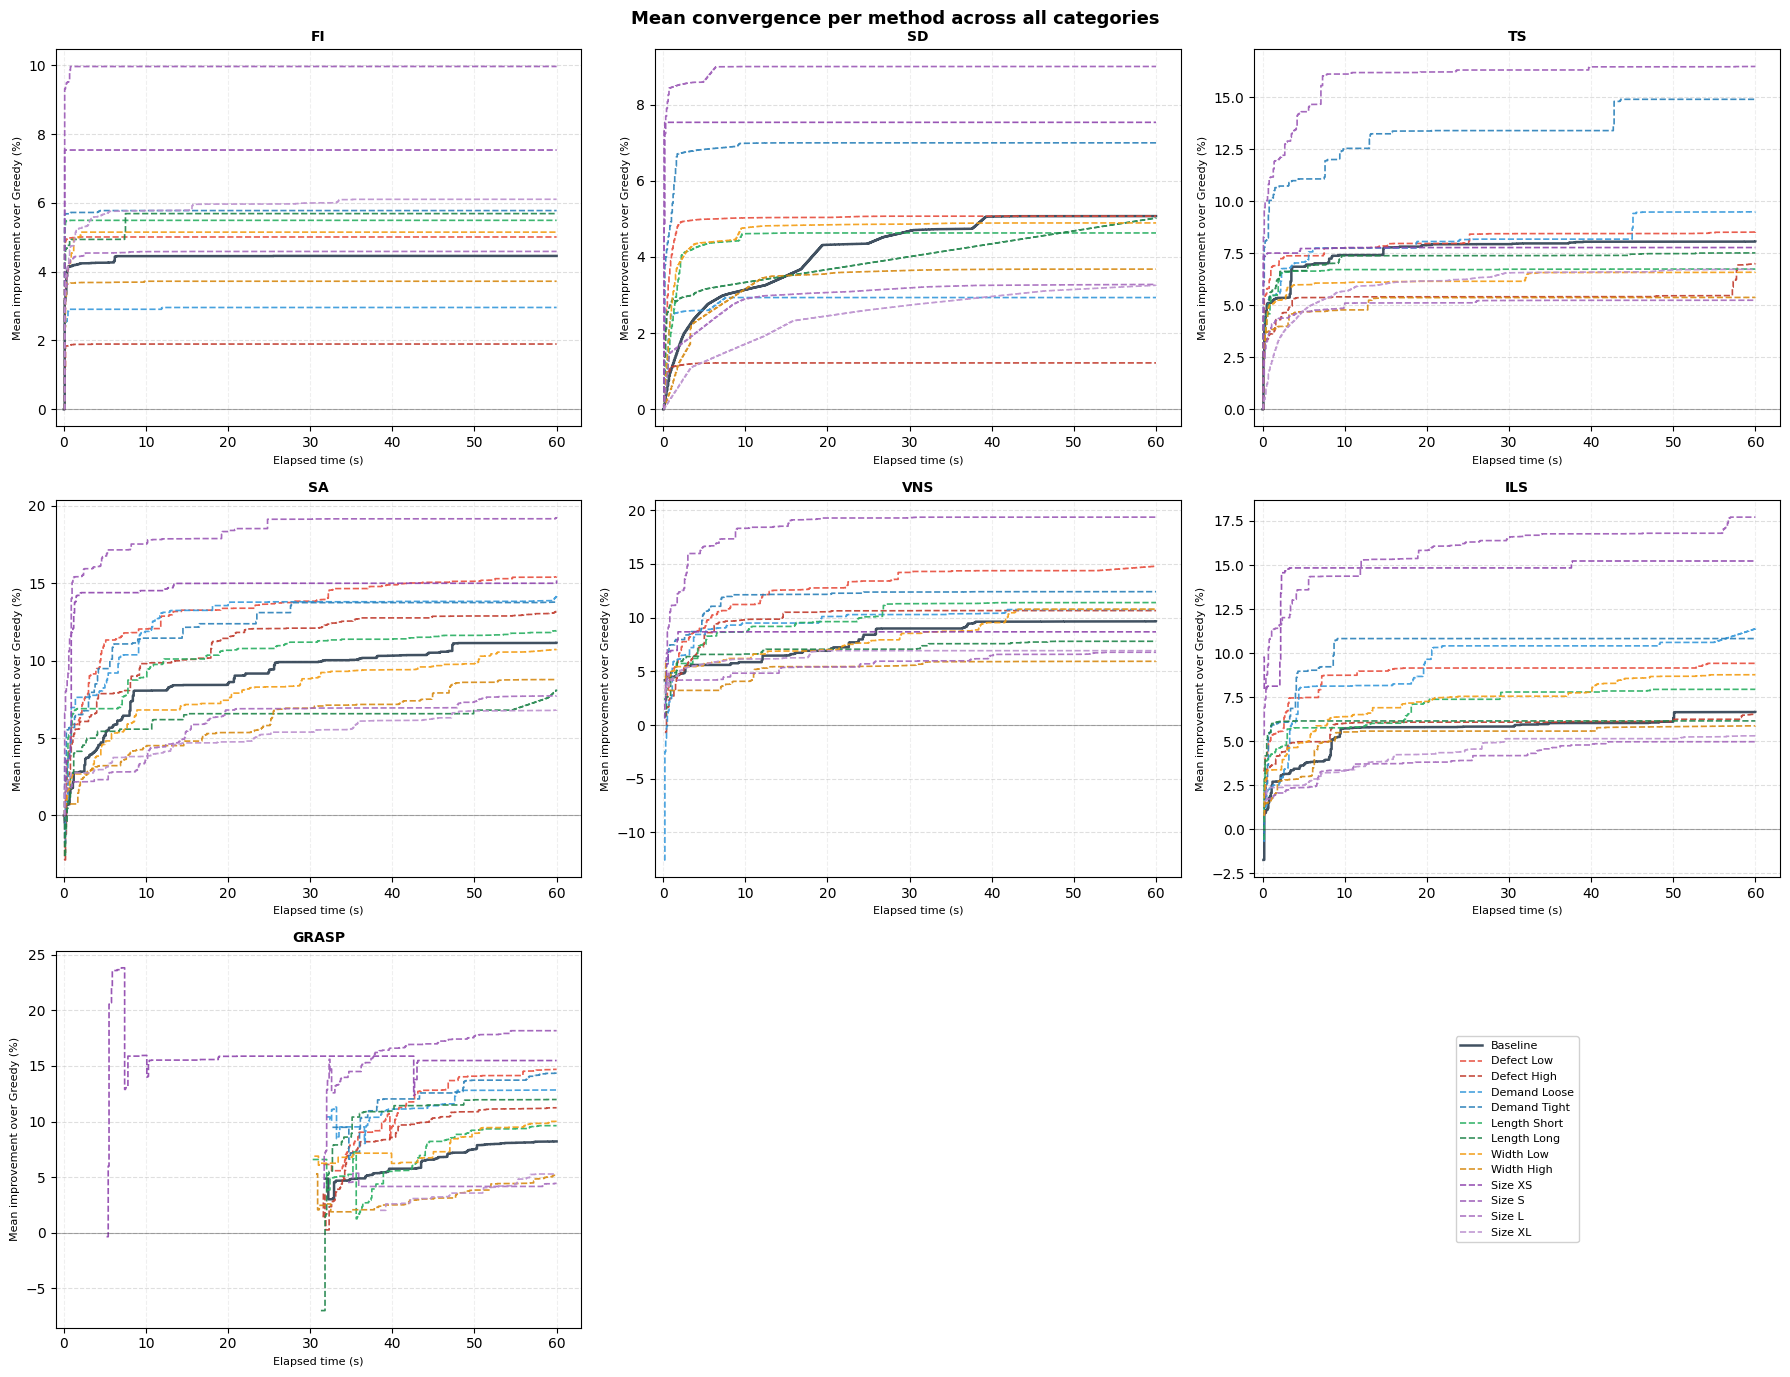

Saved to C:\Users\Isabelle\Documents\these\outputs\convergence_plots\convergence_per_method_all_categories.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import importlib

CONVERGENCE_DIR = r'C:\Users\Isabelle\Documents\these\outputs\convergence_logs'
RESULTS_PATH    = r'C:\Users\Isabelle\Documents\these\outputs\results_own_data.xlsx'
OUTPUT_DIR      = r'C:\Users\Isabelle\Documents\these\outputs\convergence_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_GRID = np.linspace(0, 60, 601)

METHODS = {
    'FI'      : {'color': '#4e79a7', 'label': 'FI'},
    'SD'      : {'color': '#76b7b2', 'label': 'SD'},
    'TS'      : {'color': '#f28e2b', 'label': 'TS'},
    'SA'      : {'color': '#e15759', 'label': 'SA'},
    'VNS_SA'  : {'color': '#59a14f', 'label': 'VNS'},
    'ILS_SA'  : {'color': '#b07aa1', 'label': 'ILS'},
    'GRASP_SA': {'color': '#9c755f', 'label': 'GRASP'},
}

CATEGORY_COLORS = {
    'baseline'    : '#2c3e50',
    'sweep1_Low'  : '#e74c3c',
    'sweep1_High' : '#c0392b',
    'sweep2_Loose': '#3498db',
    'sweep2_Tight': '#2980b9',
    'sweep3_Short': '#27ae60',
    'sweep3_Long' : '#1e8449',
    'sweep4_Low'  : '#f39c12',
    'sweep4_High' : '#d68910',
    'sweep5_XS'   : '#8e44ad',
    'sweep5_S'    : '#9b59b6',
    'sweep5_L'    : '#a569bd',
    'sweep5_XL'   : '#bb8fce',
}

CATEGORY_LABELS = {
    'baseline'    : 'Baseline',
    'sweep1_Low'  : 'Defect Low',
    'sweep1_High' : 'Defect High',
    'sweep2_Loose': 'Demand Loose',
    'sweep2_Tight': 'Demand Tight',
    'sweep3_Short': 'Length Short',
    'sweep3_Long' : 'Length Long',
    'sweep4_Low'  : 'Width Low',
    'sweep4_High' : 'Width High',
    'sweep5_XS'   : 'Size XS',
    'sweep5_S'    : 'Size S',
    'sweep5_L'    : 'Size L',
    'sweep5_XL'   : 'Size XL',
}

TAG_MAP = {
    'baseline'    : 'BASELINE',
    'sweep1_Low'  : 'SWEEP1_DEFECT_LOW',
    'sweep1_High' : 'SWEEP1_DEFECT_HIGH',
    'sweep2_Loose': 'SWEEP2_DEMAND_LOOSE',
    'sweep2_Tight': 'SWEEP2_DEMAND_TIGHT',
    'sweep3_Short': 'SWEEP3_LENRATIO_SHORT',
    'sweep3_Long' : 'SWEEP3_LENRATIO_LONG',
    'sweep4_Low'  : 'SWEEP4_WIDRATIO_LOW',
    'sweep4_High' : 'SWEEP4_WIDRATIO_HIGH',
    'sweep5_XS'   : 'SWEEP5_SIZE_XS',
    'sweep5_S'    : 'SWEEP5_SIZE_S',
    'sweep5_L'    : 'SWEEP5_SIZE_L',
    'sweep5_XL'   : 'SWEEP5_SIZE_XL',
}

# ── load greedy refs ──────────────────────────────────────────────────────────
master      = pd.read_excel(RESULTS_PATH, sheet_name='raw')
greedy_refs = master[
    (master['method'] == 'SA') &
    (master['start_method'] == 'multistart')
].set_index('instance')['greedy_ref'].to_dict()

# ── detect all instances from convergence files ───────────────────────────────
METHOD_PATTERN = (
    r'(FI_multistart|FI_greedy|FI_none'
    r'|SD_multistart|SD_greedy|SD_none'
    r'|TS_multistart|TS_greedy|TS_none'
    r'|SA_multistart|SA_greedy|SA_none'
    r'|VNS_SA_multistart|VNS_SA_greedy|VNS_SA_none'
    r'|ILS_SA_multistart|ILS_SA_greedy|ILS_SA_none'
    r'|GRASP_SA_multistart|GRASP_SA_greedy|GRASP_SA_none)'
)
FULL_PATTERN = rf'^(.+?)_{METHOD_PATTERN}_TL\d+_convergence\.csv$'

all_files = os.listdir(CONVERGENCE_DIR)
all_instances = sorted(set(
    m.group(1)
    for f in all_files
    for m in [re.match(FULL_PATTERN, f)]
    if m
))

print(f"Total instances found: {len(all_instances)}")

# ── assign instances to categories ───────────────────────────────────────────
instances_per_category = {cat: [] for cat in CATEGORY_LABELS}
for name in all_instances:
    for cat, tag in TAG_MAP.items():
        if tag in name.upper():
            instances_per_category[cat].append(name)
            break

for cat, insts in instances_per_category.items():
    print(f"  {cat}: {len(insts)} instances")

# ── interpolation helper ──────────────────────────────────────────────────────
def load_and_interpolate(instance_name, method, greedy_ref):
    fpath = None
    for start in ['multistart', 'greedy', 'none']:
        candidate = os.path.join(
            CONVERGENCE_DIR,
            f"{instance_name}_{method}_{start}_TL60_convergence.csv"
        )
        if os.path.exists(candidate):
            fpath = candidate
            break

    if fpath is None:
        return None

    df = pd.read_csv(fpath)
    if df.empty:
        return None

    df['best_cost']   = df['best_cost'].cummin()  
    df['improvement'] = (greedy_ref - df['best_cost']) / greedy_ref * 100

    if method not in ('GRASP_SA', 'VNS_SA', 'ILS_SA'):
        t0 = pd.DataFrame([{'elapsed_sec': 0.0, 'improvement': 0.0}])
        df = pd.concat([t0, df[['elapsed_sec', 'improvement']]], ignore_index=True)

    df = df.drop_duplicates('elapsed_sec').sort_values('elapsed_sec')

    return np.interp(
        TIME_GRID,
        df['elapsed_sec'].values,
        df['improvement'].values,
        left=np.nan,
        right=df['improvement'].values[-1]
    )

# ── plot function ─────────────────────────────────────────────────────────────
def plot_method_all_categories(method, method_props, ax, title=None):
    for cat_key, instances in instances_per_category.items():
        curves = []
        for name in instances:
            if name not in greedy_refs:
                continue
            arr = load_and_interpolate(name, method, greedy_refs[name])
            if arr is not None:
                curves.append(arr)
        if not curves:
            continue
        matrix     = np.vstack(curves)
        mean_curve = np.nanmean(matrix, axis=0)
        ax.plot(
            TIME_GRID, mean_curve,
            color     = CATEGORY_COLORS[cat_key],
            linewidth = 1.8 if cat_key == 'baseline' else 1.2,
            linestyle = '-'  if cat_key == 'baseline' else '--',
            alpha     = 0.9,
            label     = CATEGORY_LABELS[cat_key],
            drawstyle = 'steps-post'
        )

    ax.set_xlim(-1, 63)
    ax.set_xlabel('Elapsed time (s)', fontsize=8)
    ax.set_ylabel('Mean improvement over Greedy (%)', fontsize=8)
    ax.set_title(title or method_props['label'], fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.grid(axis='x', linestyle='--', alpha=0.2)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)

# ── build grid: 3x3 for 7 methods + 1 legend ─────────────────────────────────
TARGET_METHODS = ['FI', 'SD', 'TS', 'SA', 'VNS_SA', 'ILS_SA', 'GRASP_SA']
ncols = 3
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14))
axes = axes.flatten()

for i, method in enumerate(TARGET_METHODS):
    plot_method_all_categories(
        method, METHODS[method], axes[i],
        title=METHODS[method]['label']
    )

for j in range(len(TARGET_METHODS), len(axes)):
    axes[j].set_visible(False)

# shared legend in last empty panel
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='center', fontsize=8, framealpha=0.9)
axes[-1].axis('off')
axes[-1].set_visible(True)

plt.suptitle(
    'Mean convergence per method across all categories',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, 'convergence_per_method_all_categories.png')
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved to {out_path}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import importlib

CONVERGENCE_DIR = r'C:\Users\Isabelle\Documents\these\outputs\convergence_logs'
RESULTS_PATH    = r'C:\Users\Isabelle\Documents\these\outputs\results_own_data.xlsx'
OUTPUT_DIR      = r'C:\Users\Isabelle\Documents\these\outputs\convergence_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_GRID = np.linspace(0, 60, 601)

METHODS = {
    'FI'      : {'color': '#4e79a7', 'label': 'FI'},
    'SD'      : {'color': '#76b7b2', 'label': 'SD'},
    'TS'      : {'color': '#f28e2b', 'label': 'TS'},
    'SA'      : {'color': '#e15759', 'label': 'SA'},
    'VNS_SA'  : {'color': '#59a14f', 'label': 'VNS'},
    'ILS_SA'  : {'color': '#b07aa1', 'label': 'ILS'},
    'GRASP_SA': {'color': '#9c755f', 'label': 'GRASP'},
}

CATEGORY_COLORS = {
    'baseline'    : '#2c3e50',
    'sweep1_Low'  : '#e74c3c',
    'sweep1_High' : '#c0392b',
    'sweep2_Loose': '#3498db',
    'sweep2_Tight': '#2980b9',
    'sweep3_Short': '#27ae60',
    'sweep3_Long' : '#1e8449',
    'sweep4_Low'  : '#f39c12',
    'sweep4_High' : '#d68910',
    'sweep5_XS'   : '#8e44ad',
    'sweep5_S'    : '#9b59b6',
    'sweep5_L'    : '#a569bd',
    'sweep5_XL'   : '#bb8fce',
}

CATEGORY_LABELS = {
    'baseline'    : 'Baseline',
    'sweep1_Low'  : 'Defect Low',
    'sweep1_High' : 'Defect High',
    'sweep2_Loose': 'Demand Loose',
    'sweep2_Tight': 'Demand Tight',
    'sweep3_Short': 'Length Short',
    'sweep3_Long' : 'Length Long',
    'sweep4_Low'  : 'Width Low',
    'sweep4_High' : 'Width High',
    'sweep5_XS'   : 'Size XS',
    'sweep5_S'    : 'Size S',
    'sweep5_L'    : 'Size L',
    'sweep5_XL'   : 'Size XL',
}

TAG_MAP = {
    'baseline'    : 'BASELINE',
    'sweep1_Low'  : 'SWEEP1_DEFECT_LOW',
    'sweep1_High' : 'SWEEP1_DEFECT_HIGH',
    'sweep2_Loose': 'SWEEP2_DEMAND_LOOSE',
    'sweep2_Tight': 'SWEEP2_DEMAND_TIGHT',
    'sweep3_Short': 'SWEEP3_LENRATIO_SHORT',
    'sweep3_Long' : 'SWEEP3_LENRATIO_LONG',
    'sweep4_Low'  : 'SWEEP4_WIDRATIO_LOW',
    'sweep4_High' : 'SWEEP4_WIDRATIO_HIGH',
    'sweep5_XS'   : 'SWEEP5_SIZE_XS',
    'sweep5_S'    : 'SWEEP5_SIZE_S',
    'sweep5_L'    : 'SWEEP5_SIZE_L',
    'sweep5_XL'   : 'SWEEP5_SIZE_XL',
}

# ── load greedy refs ──────────────────────────────────────────────────────────
master      = pd.read_excel(RESULTS_PATH, sheet_name='raw')
greedy_refs = master[
    (master['method'] == 'SA') &
    (master['start_method'] == 'multistart')
].set_index('instance')['greedy_ref'].to_dict()

# ── detect all instances from convergence files ───────────────────────────────
METHOD_PATTERN = (
    r'(FI_multistart|FI_greedy|FI_none'
    r'|SD_multistart|SD_greedy|SD_none'
    r'|TS_multistart|TS_greedy|TS_none'
    r'|SA_multistart|SA_greedy|SA_none'
    r'|VNS_SA_multistart|VNS_SA_greedy|VNS_SA_none'
    r'|ILS_SA_multistart|ILS_SA_greedy|ILS_SA_none'
    r'|GRASP_SA_multistart|GRASP_SA_greedy|GRASP_SA_none)'
)
FULL_PATTERN = rf'^(.+?)_{METHOD_PATTERN}_TL\d+_convergence\.csv$'

all_files = os.listdir(CONVERGENCE_DIR)
all_instances = sorted(set(
    m.group(1)
    for f in all_files
    for m in [re.match(FULL_PATTERN, f)]
    if m
))

print(f"Total instances found: {len(all_instances)}")

# ── assign instances to categories ───────────────────────────────────────────
instances_per_category = {cat: [] for cat in CATEGORY_LABELS}
for name in all_instances:
    for cat, tag in TAG_MAP.items():
        if tag in name.upper():
            instances_per_category[cat].append(name)
            break

for cat, insts in instances_per_category.items():
    print(f"  {cat}: {len(insts)} instances")

# ── interpolation helper ──────────────────────────────────────────────────────
def load_and_interpolate(instance_name, method, greedy_ref):
    fpath = None
    for start in ['multistart', 'greedy', 'none']:
        candidate = os.path.join(
            CONVERGENCE_DIR,
            f"{instance_name}_{method}_{start}_TL60_convergence.csv"
        )
        if os.path.exists(candidate):
            fpath = candidate
            break

    if fpath is None:
        return None

    df = pd.read_csv(fpath)
    if df.empty:
        return None

    #df['best_cost']   = df['best_cost'].cummin()  
    df['improvement'] = (greedy_ref - df['best_cost']) / greedy_ref * 100

    if method not in ('GRASP_SA', 'VNS_SA', 'ILS_SA'):
        t0 = pd.DataFrame([{'elapsed_sec': 0.0, 'improvement': 0.0}])
        df = pd.concat([t0, df[['elapsed_sec', 'improvement']]], ignore_index=True)

    df = df.drop_duplicates('elapsed_sec').sort_values('elapsed_sec')

    return np.interp(
        TIME_GRID,
        df['elapsed_sec'].values,
        df['improvement'].values,
        left=np.nan,
        right=df['improvement'].values[-1]
    )

# ── plot function ─────────────────────────────────────────────────────────────
def plot_method_all_categories(method, method_props, ax, title=None):
    for cat_key, instances in instances_per_category.items():
        curves = []
        for name in instances:
            if name not in greedy_refs:
                continue
            arr = load_and_interpolate(name, method, greedy_refs[name])
            if arr is not None:
                curves.append(arr)
        if not curves:
            continue
        matrix     = np.vstack(curves)
        mean_curve = np.nanmean(matrix, axis=0)
        ax.plot(
            TIME_GRID, mean_curve,
            color     = CATEGORY_COLORS[cat_key],
            linewidth = 1.8 if cat_key == 'baseline' else 1.2,
            linestyle = '-'  if cat_key == 'baseline' else '--',
            alpha     = 0.9,
            label     = CATEGORY_LABELS[cat_key],
            drawstyle = 'steps-post'
        )

    ax.set_xlim(-1, 63)
    ax.set_xlabel('Elapsed time (s)', fontsize=8)
    ax.set_ylabel('Mean improvement over Greedy (%)', fontsize=8)
    ax.set_title(title or method_props['label'], fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.grid(axis='x', linestyle='--', alpha=0.2)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)

# ── build grid: 3x3 for 7 methods + 1 legend ─────────────────────────────────
TARGET_METHODS = ['FI', 'SD', 'TS', 'SA', 'VNS_SA', 'ILS_SA', 'GRASP_SA']
ncols = 3
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14))
axes = axes.flatten()

for i, method in enumerate(TARGET_METHODS):
    plot_method_all_categories(
        method, METHODS[method], axes[i],
        title=METHODS[method]['label']
    )

for j in range(len(TARGET_METHODS), len(axes)):
    axes[j].set_visible(False)

# shared legend in last empty panel
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='center', fontsize=8, framealpha=0.9)
axes[-1].axis('off')
axes[-1].set_visible(True)

plt.suptitle(
    'Mean convergence per method across all categories',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, 'convergence_per_method_all_categories_erratic.png')
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved to {out_path}")

In [ ]:
import pandas as pd
import re
import os
import pdfplumber
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

EXCEL_PATH  = r"C:\Users\Isabelle\Documents\these\Data\omp_mistakes_enriched.xlsx"
PDF_DIR     = r"C:\Users\Isabelle\Documents\these\Data\omp_pdfs"
OUTPUT_PATH = r"C:\Users\Isabelle\Documents\these\outputs\omp_costs.xlsx"

df = pd.read_excel(EXCEL_PATH, sheet_name='proposals_by_instance')

def parse_proposals_from_string(proposals_str):
    if not isinstance(proposals_str, str) or proposals_str.strip() == 'none':
        return {}
    selected = {}
    for match in re.finditer(r'(C\d+)\s+\(x(\d+)\)', proposals_str):
        prop_id = match.group(1)
        n_reps  = int(match.group(2))
        selected[prop_id] = selected.get(prop_id, 0) + n_reps
    return selected

def parse_proposals_from_pdf(pdf_path):
    """Parse selected proposals from OMP PDF."""
    selected = {}
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text and 'Selected Proposals' in text:
                for line in text.split('\n'):
                    m = re.match(r'^(C\d+)\s+(\d+)$', line.strip())
                    if m:
                        prop_id = m.group(1)
                        n_reps  = int(m.group(2))
                        selected[prop_id] = selected.get(prop_id, 0) + n_reps
    return selected

def compute_omp_cost_from_selected(selected, proposals_raw, stocks):
    proposals_by_id = {p.proposal_id: p for p in proposals_raw}
    opened_stocks   = set()
    by_stock        = {}
    missing         = []

    for prop_id, n_reps in selected.items():
        if prop_id not in proposals_by_id:
            missing.append(prop_id)
            continue
        prop     = proposals_by_id[prop_id]
        stock_id = prop.stock_id
        if stock_id not in by_stock:
            by_stock[stock_id] = []
        by_stock[stock_id].append((prop_id, prop, n_reps))

    activation_cost = 0.0
    setup_cost      = 0.0
    rep_cost        = 0.0

    for stock_id, entries in by_stock.items():
        activation_cost += stocks[stock_id].cost
        opened_stocks.add(stock_id)
        for _, prop, n_reps in entries:
            setup_cost += prop.setup_cost
            rep_cost   += prop.cost_per_repetition * n_reps

    total_cost = activation_cost + setup_cost + rep_cost
    return round(total_cost, 4), round(activation_cost, 4), \
           round(setup_cost, 4), round(rep_cost, 4), \
           len(opened_stocks), missing

instances_by_name = {i['name']: i for i in instances}

results = []
for _, row in df.iterrows():
    name     = row['instance']
    instance = instances_by_name.get(name)
    if instance is None:
        print(f"  [skip] {name} — not loaded")
        continue

    # try Excel first
    shown_str  = row.get('proposals_shown', '')
    hidden_str = row.get('proposals_hidden', '')
    combined   = str(shown_str or '') + ' ' + str(hidden_str or '')
    selected   = parse_proposals_from_string(combined)
    source     = 'excel'

    # fallback to PDF if no proposals found in Excel
    if not selected:
        pdf_path = os.path.join(PDF_DIR, f"{name}.pdf")
        if os.path.exists(pdf_path):
            selected = parse_proposals_from_pdf(pdf_path)
            source   = 'pdf'
        else:
            print(f"  [skip] {name} — no proposals in Excel and no PDF found")
            continue

    if not selected:
        print(f"  [skip] {name} — no proposals found in Excel or PDF")
        continue

    cost, act_cost, set_cost, rep_cost, n_stocks, missing = \
        compute_omp_cost_from_selected(
            selected, instance['proposals_raw'], instance['stocks']
        )

    print(f"  {name}  cost={cost:.2f}  stocks={n_stocks}  "
          f"source={source}"
          + (f"  missing={missing}" if missing else ""))

    results.append({
        'instance'         : name,
        'omp_cost'         : cost,
        'activation_cost'  : act_cost,
        'setup_cost'       : set_cost,
        'repetition_cost'  : rep_cost,
        'n_stocks_opened'  : n_stocks,
        'n_proposals_used' : len(selected),
        'source'           : source,
        'missing_proposals': ', '.join(missing) if missing else '',
    })

df_out = pd.DataFrame(results)

# styling
HDR_FILL  = PatternFill('solid', start_color='2C3E50')
HDR_FONT  = Font(bold=True, color='FFFFFF', name='Arial', size=9)
EVEN_FILL = PatternFill('solid', start_color='F2F2F2')
ODD_FILL  = PatternFill('solid', start_color='FFFFFF')
BODY_FONT = Font(name='Arial', size=9)
CENTER    = Alignment(horizontal='center', vertical='center')
LEFT      = Alignment(horizontal='left',   vertical='center')
thin      = Side(style='thin', color='CCCCCC')
BORDER    = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'OMP Costs'
ws.freeze_panes = 'B2'

headers = list(df_out.columns)
for ci, h in enumerate(headers, 1):
    cell = ws.cell(row=1, column=ci, value=h)
    cell.font = HDR_FONT; cell.fill = HDR_FILL
    cell.alignment = CENTER; cell.border = BORDER

for ri, row in enumerate(df_out.itertuples(index=False), 2):
    for ci, val in enumerate(row, 1):
        cell = ws.cell(row=ri, column=ci, value=val)
        cell.font      = BODY_FONT
        cell.fill      = EVEN_FILL if ri % 2 == 0 else ODD_FILL
        cell.alignment = CENTER if ci > 1 else LEFT
        cell.border    = BORDER
        if isinstance(val, float):
            cell.number_format = '0.00'

ws.column_dimensions['A'].width = 38
for ci in range(2, len(headers)+1):
    ws.column_dimensions[get_column_letter(ci)].width = 16

wb.save(OUTPUT_PATH)
print(f"\nDone. Saved to {OUTPUT_PATH}")
print(df_out.to_string(index=False))